In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_dataset(path, file, date_col=None):
    '''
    path: is the folder where the file exists.
    file: is the csv file.
    date_col: the date column that is supposed to be specified as the index.
    
    returns: a panda dataframe with DatetimeIndex.
    '''
    df = pd.read_csv(path / file, index_col=date_col)
    
    return df

In [6]:
def plot_dfs(df1, df2, col, title=None, xlabel=None, ylabel=None):
    '''
    df1: original dataframe without missing data
    df2: dataframe with missing data
    col: column with name that contains missing data
    title: plot title
    xlabel: label of x-axis
    ylabel: label of y-axis

    returns:
    '''
    df_missing = df2.rename(columns={ col: 'missing' })

    columns = df_missing.loc[:, 'missing':].columns.tolist()
    subplots_size = len(columns)
    fig, ax = plt.subplots(subplots_size+1, 1, sharex=True)
    plt.subplots_adjust(hspace=0.25)
    fig.suptitle = title

    df1[col].plot(ax=ax[0], figsize=(10, 12))
    ax[0].set_title(title)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel(ylabel)

    for i, colname in enumerate(columns):
        df_missing[colname].plot(ax=ax[i+1])
        ax[i+1].set_title(colname.upper())

    plt.show()

In [7]:
def rmse_score(df1, df2, col=None):
    '''
    df1: original dataframe without missing data
    df2: dataframe with missing data
    col: column name that contains missing data
    returns: a list of scores
    '''
    df_missing = df2.rename(columns={ col: 'missing' })
    columns = df_missing.loc[:, 'missing':].columns.tolist()
    scores = []
    for comp_col in columns[1:]:
        rmse = np.sqrt(np.mean((df1[col] - df_missing[comp_col])**2))
        scores.append(rmse)
        print(f'RMSE for {comp_col}: {rmse}')
    
    return scores

### Handling data quality checks

In [8]:
co2 = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch7/co2_missing.csv')
ecom = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch7/clicks_missing.csv')

co2_df = pd.read_csv(co2, index_col='year', parse_dates=True)
ecom_df = pd.read_csv(ecom, index_col='date', parse_dates=True)

ecom_df.head()

/tmp/ipykernel_6782/2123207656.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ecom_df = pd.read_csv(ecom, index_col='date', parse_dates=True)


,price,location,clicks
date,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
2008-04-03,43.842609,2,15209.0
2008-04-04,43.312376,1,14018.0
2008-04-05,43.941176,1,11974.0


In [9]:
co2_df.head()

,co2
year,
1750-01-01,0.0125
1760-01-01,0.0128
1770-01-01,0.0150
1780-01-01,0.0169
1790-01-01,0.0206


In [10]:
co2_df.isnull().sum()

co2    25
dtype: int64

In [12]:
ecom_df.isnull().sum().sum()

np.int64(16)

In [13]:
co2_df.isnull().values.any()

np.True_

In [15]:
ecom_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 135 entries, 2008-04-01 to 2008-08-13
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     135 non-null    float64
 1   location  135 non-null    int64  
 2   clicks    119 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.2 KB


In [18]:
co2_df.describe(include='all')

,co2
count,201.000000
mean,1.590015
std,1.644182
min,0.000000
25%,0.076400
50%,0.935100
75%,2.807600
max,4.907900


In [21]:
ecom_df.describe(include='all')

,price,location,clicks
count,135.000000,135.000000,119.000000
mean,43.478978,1.696296,9530.336134
std,0.608467,1.114853,4687.587507
min,42.207018,1.000000,2044.000000
25%,43.045714,1.000000,6438.000000
50%,43.487069,1.000000,8391.000000
75%,43.886875,2.000000,11363.500000
max,45.801613,5.000000,29505.000000


In [28]:
ecom_df['clicks'].nunique()

118

In [30]:
ecom_df['clicks'].value_counts()

clicks
7106.0     2
18784.0    1
7608.0     1
8382.0     1
8404.0     1
          ..
6361.0     1
9313.0     1
7909.0     1
2044.0     1
2922.0     1
Name: count, Length: 118, dtype: int64

In [32]:
ecom_q = ecom_df['clicks'] == '?'
ecom_q = ecom_df[ecom_q]
ecom_q

,price,location,clicks
date,,,


In [33]:
co2_df.replace(0, np.nan, inplace=True)
ecom_df.replace('?', np.nan, inplace=True)
ecom_df['clicks'] = ecom_df['clicks'].astype('float')

co2_df.isnull().sum()

co2    35
dtype: int64

In [34]:
ecom_df.isnull().sum()

price        0
location     0
clicks      16
dtype: int64

In [35]:
co2_df.shape

(226, 1)

### Handling missing data with univariate imputation using pandas

In [37]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch7')
co2_original = pd.read_csv(path / 'co2_original.csv')
co2_missing = pd.read_csv(path / 'co2_missing_only.csv')
clicks_original = pd.read_csv(path / 'clicks_original.csv')
clicks_missing = pd.read_csv(path / 'clicks_missing.csv')

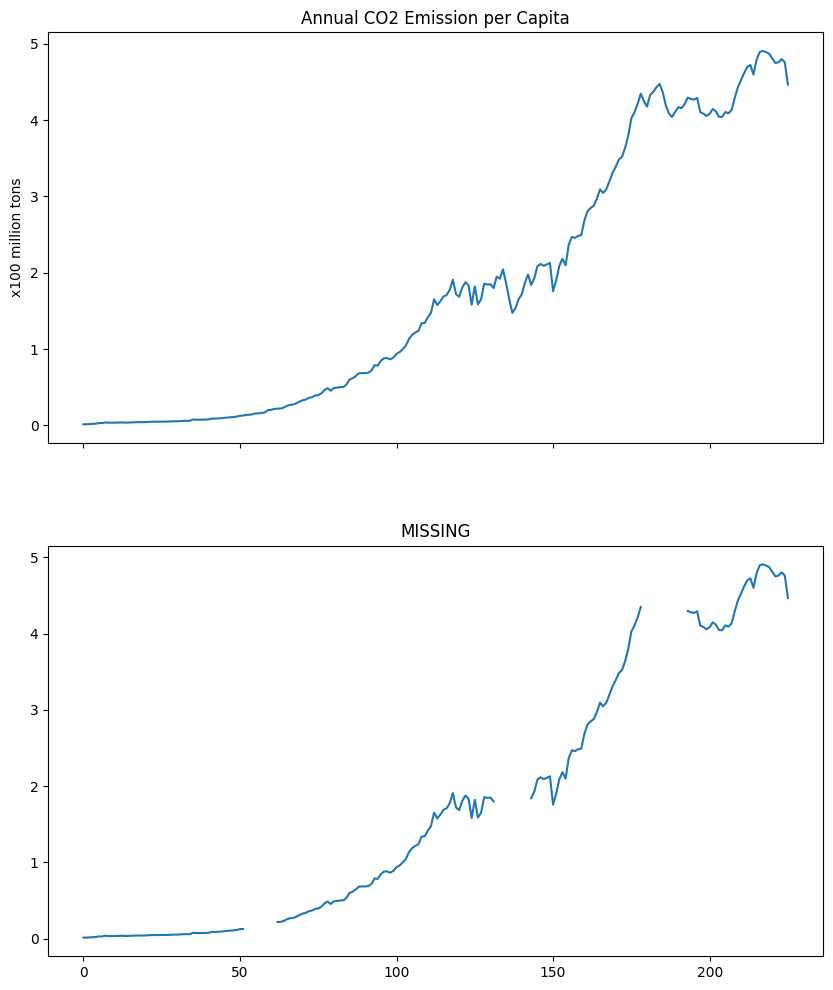

In [38]:
plot_dfs(co2_original, co2_missing, col='co2',
         title="Annual CO2 Emission per Capita",
         xlabel="Years",
         ylabel="x100 million tons")

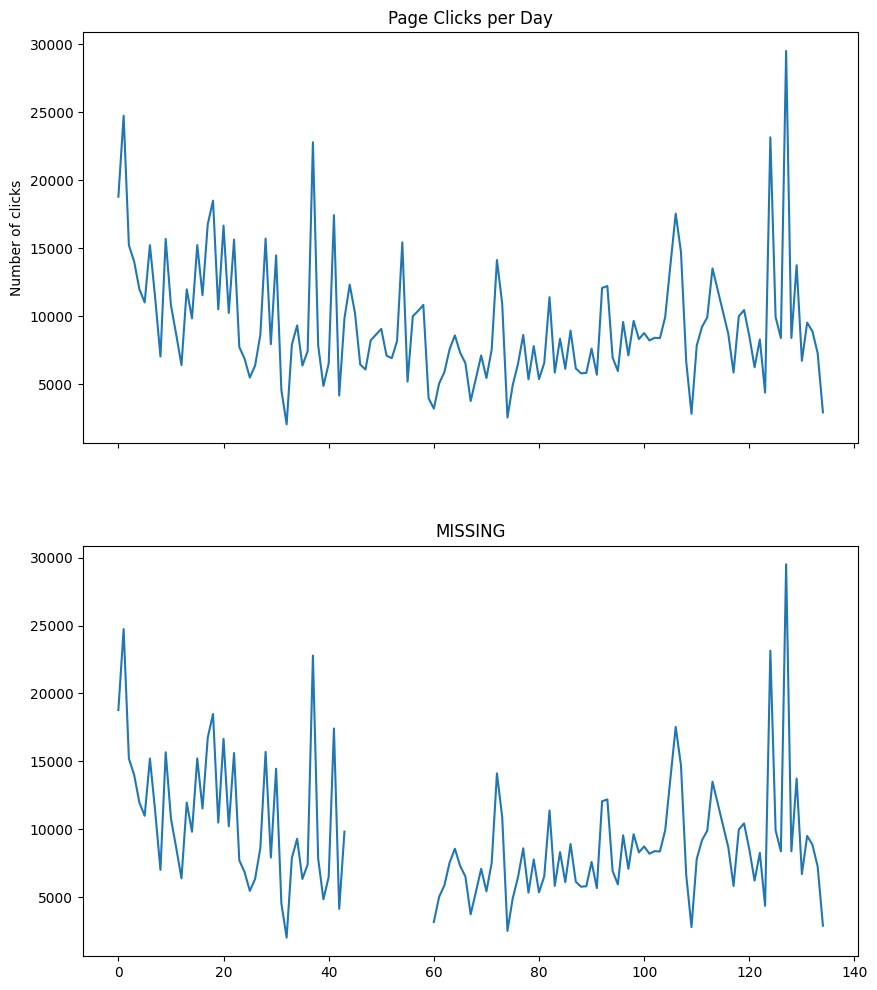

In [39]:
plot_dfs(clicks_original, clicks_missing, 'clicks',
         title="Page Clicks per Day",
         xlabel="date",
         ylabel="Number of clicks")

In [40]:
clicks_missing[clicks_missing['clicks'].isna()]

,date,price,location,clicks
44,5/15/08,42.517755,2,NaN
45,5/16/08,44.011009,2,NaN
46,5/17/08,42.530303,2,NaN
47,5/18/08,42.565698,5,NaN
48,5/19/08,43.892996,2,NaN
49,5/20/08,43.247706,2,NaN
50,5/21/08,44.106289,1,NaN
51,5/22/08,43.810714,1,NaN
52,5/23/08,43.620802,1,NaN
53,5/24/08,43.854031,2,NaN


In [41]:
co2_missing['ffill'] = co2_missing['co2'].fillna(method='ffill')
co2_missing['bfill'] = co2_missing['co2'].fillna(method='bfill')
co2_missing['mean'] = co2_missing['co2'].fillna(co2_missing['co2'].mean(), axis=0)

/tmp/ipykernel_6782/223562203.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  co2_missing['ffill'] = co2_missing['co2'].fillna(method='ffill')
/tmp/ipykernel_6782/223562203.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  co2_missing['bfill'] = co2_missing['co2'].fillna(method='bfill')


In [42]:
_ = rmse_score(co2_original, co2_missing, 'co2')

RMSE for ffill: 0.05873012599267133
RMSE for bfill: 0.05550012995280968
RMSE for mean: 0.7156383637041684


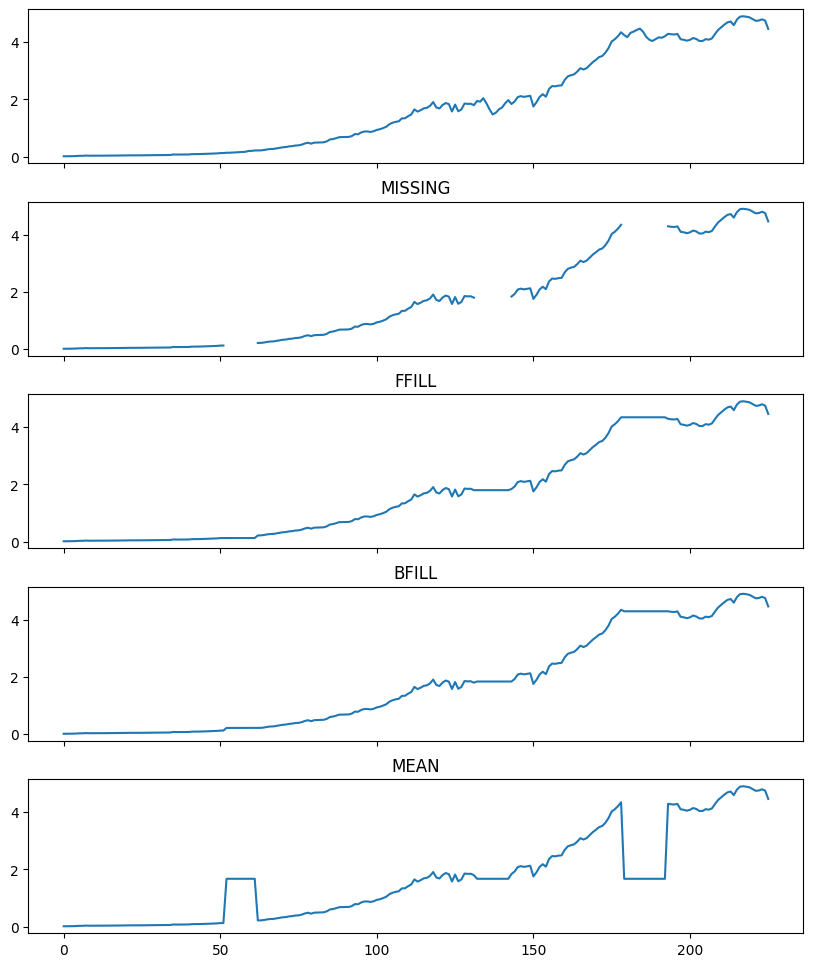

In [43]:
plot_dfs(co2_original, co2_missing, 'co2')

In [45]:
clicks_missing['ffill'] = clicks_missing['clicks'].fillna(method='ffill', axis=0)
clicks_missing['bfill'] = clicks_missing['clicks'].fillna(method='bfill', axis=0)
clicks_missing['mean'] = clicks_missing['clicks'].fillna(clicks_missing['clicks'].mean(), axis=0)

rmse_score(clicks_original, clicks_missing, 'clicks')

RMSE for ffill: 1034.1210689204554
RMSE for bfill: 2116.6840489225033
RMSE for mean: 997.7600138929953


/tmp/ipykernel_6782/3007893173.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clicks_missing['ffill'] = clicks_missing['clicks'].fillna(method='ffill', axis=0)
/tmp/ipykernel_6782/3007893173.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clicks_missing['bfill'] = clicks_missing['clicks'].fillna(method='bfill', axis=0)


[np.float64(1034.1210689204554),
 np.float64(2116.6840489225033),
 np.float64(997.7600138929953)]

The mean has the lowest RMSE score.

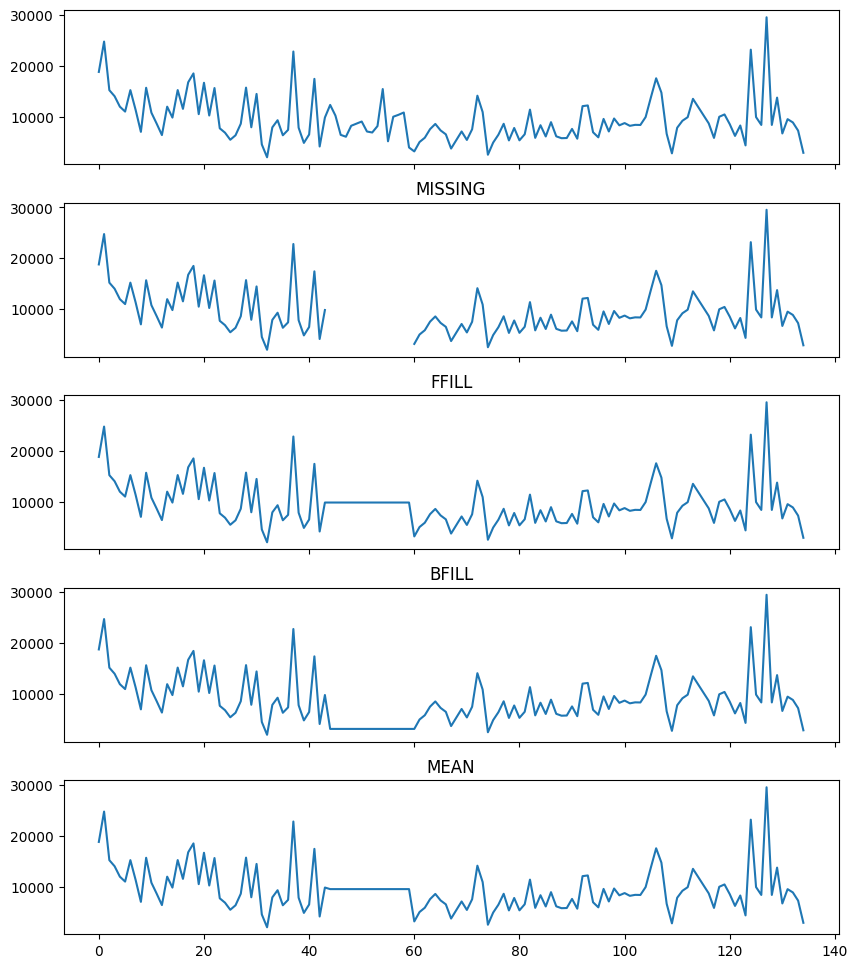

In [46]:
plot_dfs(clicks_original, clicks_missing, 'clicks')

In [ ]:
co2_missing['co2'].ffill()
co2_missing['co2'].bfill()

### Handling missing data with univariate imputation using scikit-learn

In [50]:
from sklearn.impute import SimpleImputer

co2_original = read_dataset(path, 'co2_original.csv', 'year')
co2_missing = read_dataset(path, 'co2_missing_only.csv', 'year')
clicks_original = read_dataset(path, 'clicks_original.csv', 'date')
clicks_missing = read_dataset(path, 'clicks_missing.csv', 'date')

strategy = [
    ('Mean Strategy', 'mean'),
    ('Median Strategy', 'median'),
    ('Mode Strategy', 'most_frequent')
]

co2_values = co2_missing['co2'].values.reshape(-1, 1)
clicks_values = clicks_missing['clicks'].values.reshape(-1, 1)
for s_name, s in strategy:
    co2_missing[s_name] = (SimpleImputer(strategy=s).fit_transform(co2_values))
    clicks_missing[s_name] = (SimpleImputer(strategy=s).fit_transform(clicks_values))

_ = rmse_score(co2_original, co2_missing, 'co2')

RMSE for Mean Strategy: 0.7156383637041684
RMSE for Median Strategy: 0.802942160685986
RMSE for Mode Strategy: 1.1245663822743381


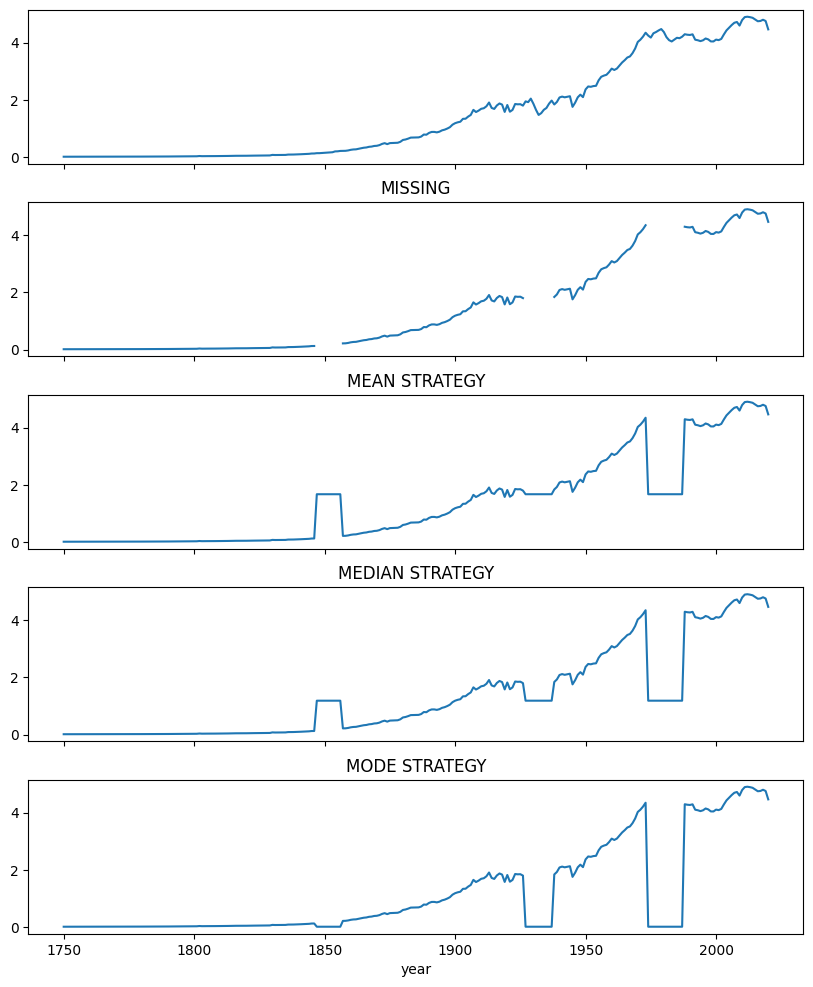

In [51]:
plot_dfs(co2_original, co2_missing, 'co2')

In [53]:
_ = rmse_score(clicks_original, clicks_missing, 'clicks')

RMSE for Mean Strategy: 997.7600138929953
RMSE for Median Strategy: 959.3580492530756
RMSE for Mode Strategy: 1097.6425985146868


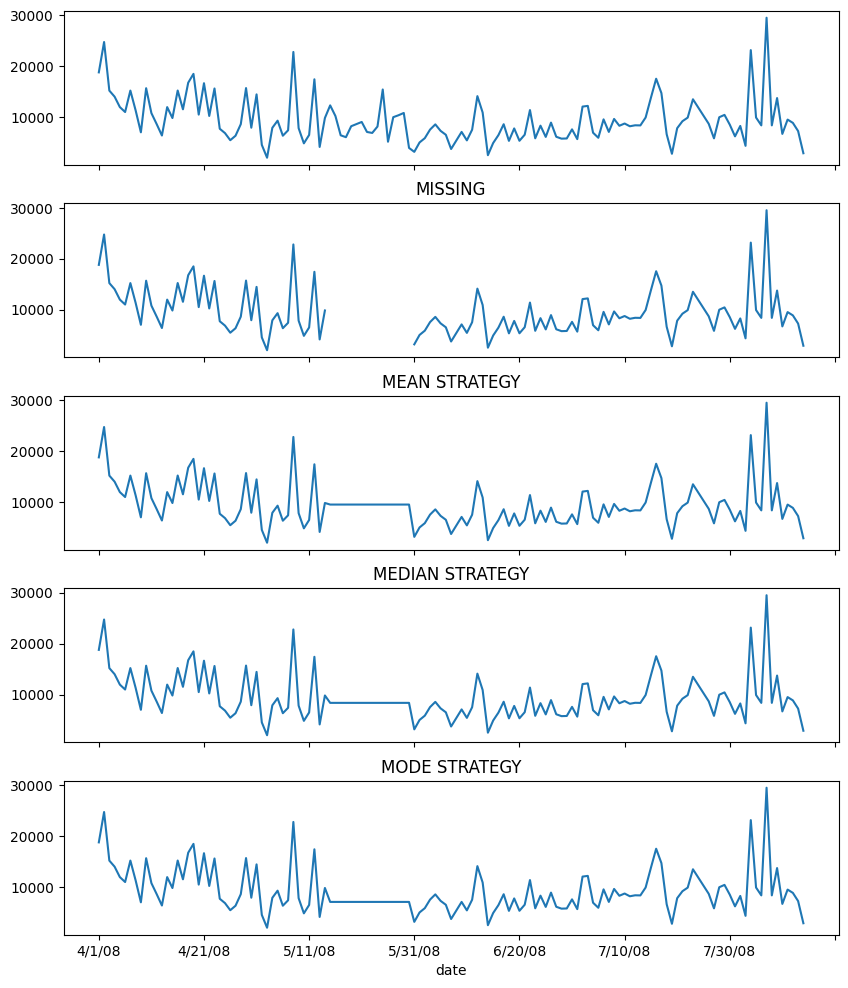

In [54]:
plot_dfs(clicks_original, clicks_missing, 'clicks')

### Handling missing data with multivariate imputation
-----
**Note** In other words, univariate imputation methods handle missing values for a particular
variable in isolation of the entire dataset and just focus on that variable to derive the
estimates. In multivariate imputation, the assumption is that there is some synergy within
the variables in the dataset, and collectively, they can provide better estimates to fill in for
the missing values.

In [55]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor, BaggingRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [67]:
clicks_original = read_dataset(path, 'clicks_original.csv', 'date')
clicks_missing = read_dataset(path, 'clicks_missing.csv', 'date')

In [68]:
estimators = [
    ('extra_trees', ExtraTreesRegressor(n_estimators=10)),
    ('bagging', BaggingRegressor(n_estimators=10)),
    ('bayesian_ridge', ElasticNet()),
    ('linear_regression', LinearRegression(fit_intercept=True)),
    ('knn', KNeighborsRegressor(n_neighbors=3))
]

In [69]:
clicks_values = clicks_missing.iloc[:, 0:3].values
for e_name, e in estimators:
    estimator = IterativeImputer(
        random_state=15, estimator=e
    ).fit(clicks_values)
    clicks_missing[e_name] = estimator.transform(clicks_values)[:, 2]

/home/jeremy/Work/Data Science/Learning/kaggle-ml/venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/jeremy/Work/Data Science/Learning/kaggle-ml/venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [70]:
_ = rmse_score(clicks_original, clicks_missing, 'clicks')

RMSE for extra_trees: 1893.4717801689826
RMSE for bagging: 1282.4699247646806
RMSE for bayesian_ridge: 945.40752093431
RMSE for linear_regression: 938.9419831427186
RMSE for knn: 1336.8798392251822


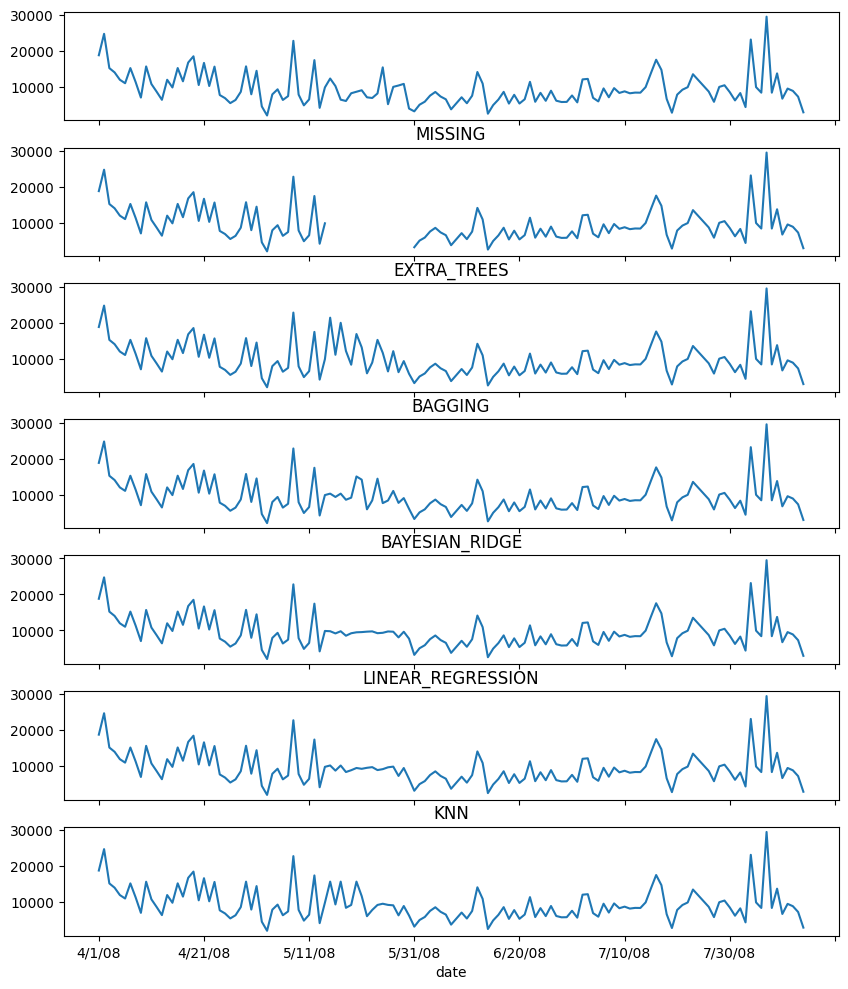

In [71]:
plot_dfs(clicks_original, clicks_missing, 'clicks')

In [72]:
from statsmodels.imputation.mice import MICE, MICEData, MICEResults
import statsmodels.api as sm

# create a MICEData object
fltr = ['price', 'location','clicks']
mice_data = MICEData(clicks_missing[fltr],
perturbation_method='gaussian')

# 20 iterations
mice_data.update_all(n_iter=20)
mice_data.set_imputer('clicks', formula='~ price + location',
model_class=sm.OLS)

In [73]:
clicks_missing['MICE'] = mice_data.data['clicks'] \
    .values \
    .tolist()
_ = rmse_score(clicks_original, clicks_missing, 'clicks')

RMSE for extra_trees: 1893.4717801689826
RMSE for bagging: 1282.4699247646806
RMSE for bayesian_ridge: 945.40752093431
RMSE for linear_regression: 938.9419831427186
RMSE for knn: 1336.8798392251822
RMSE for MICE: 1627.732990661825


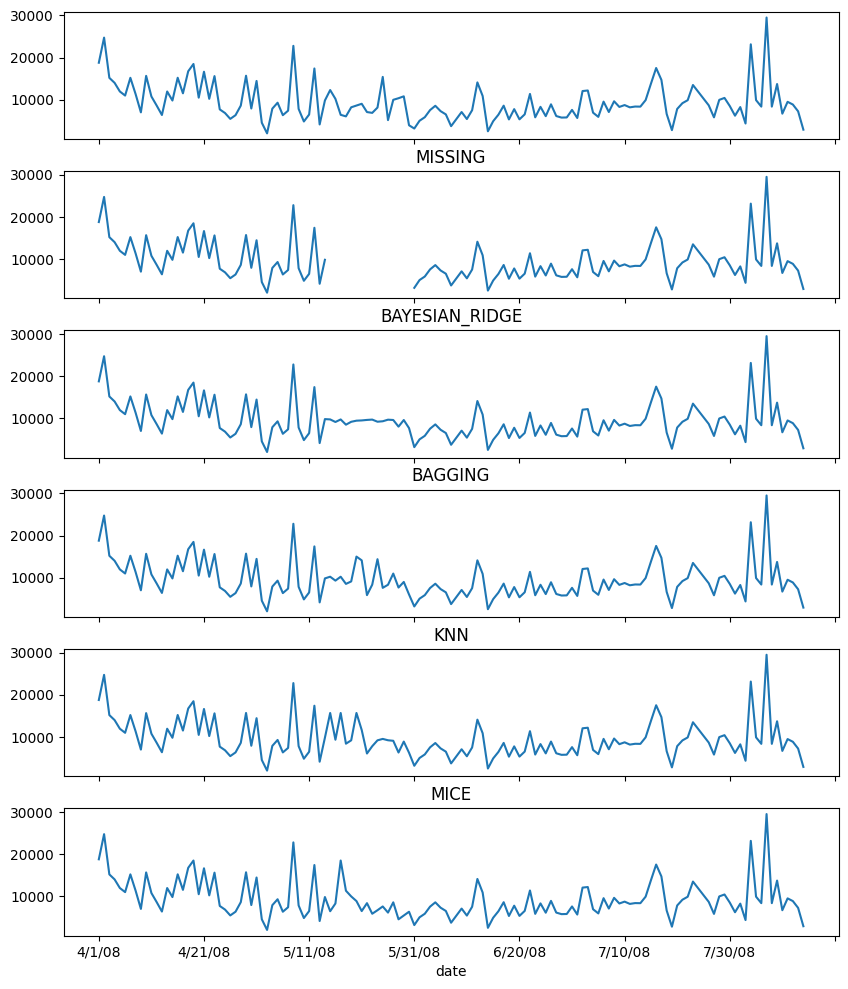

In [74]:
cols = ['clicks', 'bayesian_ridge', 'bagging', 'knn', 'MICE']
plot_dfs(clicks_original, clicks_missing[cols], 'clicks')

### Handling missing data with interpolation

In [80]:
co2_original = read_dataset(path, 'co2_original.csv', 'year')
co2_missing = read_dataset(path, 'co2_missing_only.csv', 'year')
clicks_original = read_dataset(path, 'clicks_original.csv', 'date')
clicks_missing = read_dataset(path, 'clicks_missing.csv', 'date')

In [82]:
co2_original.columns

Index(['co2'], dtype='object')

In [83]:
# co2_original.index.astype('int')
# co2_missing.index.astype('int')
# clicks_original.index.astype('int')
# clicks_missing.index.astype('int')

interpolations = ['linear','quadratic','nearest','cubic']

for intp in interpolations:
    co2_missing[intp] = co2_missing['co2'].interpolate(method=intp)
    clicks_missing[intp] = clicks_missing['clicks'].interpolate(method=intp)

ValueError: Index column must be numeric or datetime type when using quadratic method other than linear. Try setting a numeric or datetime index column before interpolating.

In [ ]:
co2_missing['spline'] = co2_missing['co2'].interpolate(method='spline', order=2)
clicks_missing['spline'] = clicks_missing['clicks'].interpolate(method='spline',order=2)
co2_missing['polynomial'] = co2_missing['co2'].interpolate(method='polynomial',order=5)
clicks_missing['polynomial'] = clicks_missing['clicks'].interpolate(method='polynomial',order=5)

In [ ]:
_ = rmse_score(co2_original, co2_missing, 'co2')

In [ ]:
cols = ['co2', 'linear', 'nearest', 'polynomial']
plot_dfs(co2_original, co2_missing[cols], 'co2')

In [ ]:
cols = ['clicks', 'linear', 'nearest', 'polynomial',
'spline']
plot_dfs(clicks_original, clicks_missing[cols], 'clicks')